# LeNet

## Overview

LeNet is one of the earliest successful Convolutional Neural Network (CNN) architectures. It was proposed by Yann LeCun in 1998 for handwritten digit recognition and laid the foundation for modern deep learning in computer vision.

## Key Features

- Introduced the concept of convolutional and pooling layers.
- Designed for grayscale images.
- Uses a simple sequential architecture.
- Consists of convolution, pooling, fully connected layers, and an output layer.

## Architecture Summary

Input Image
→ Convolution Layer
→ Average Pooling
→ Convolution Layer
→ Average Pooling
→ Fully Connected Layer
→ Fully Connected Layer
→ Output Layer

## Applications

- Handwritten digit recognition
- Character recognition
- Basic image classification tasks

## Limitations

- Very shallow network.
- Designed for small grayscale images.
- Limited feature extraction capability compared to modern CNNs.

In [12]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt

In [13]:
mnist = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

## 1. LeNet

In [14]:
X_train.shape 
# Now we need to make it 32x32 to match the LeNet

(60000, 28, 28)

### Padding Images

In [15]:
np.pad(np.array([[1,1],[2,2]]), ((2,1), (0,0))) 
# one padding at the bottom, 2 at the top and no on the columns

array([[0, 0],
       [0, 0],
       [1, 1],
       [2, 2],
       [0, 0]])

In [16]:
# Padding to match 32x32 input size for LeNet
X_train = np.pad(X_train, ((0,0), (2,2), (2,2)), 'constant').astype('float32') / 255.0
X_test = np.pad(X_test, ((0,0), (2,2), (2,2)), 'constant').astype('float32') / 255.0 
## We divide by 255 to normalise the pixel values
# How much padding to add. This is the most important part. Padding for axis 1, then for axis 2 and then for axis 3. Two rows/columns of 0's will be 
# added to that dimension

### Extending Dimensions
CNN architecture requires dimensions to be extended because the input requires grid like structures info. This wasnt the case in FFNN, where you just had one neuron each for a feature (pixel value). \
Always use channels last data format as it is the defualt mode of operation in Keras. 

In [17]:
# Since the dataset is 60k x 32 x 32 now, there is no channel info. 
# We know that it's grayscale, so I need to make it 60k * 1 * 32 * 32
X_train = np.expand_dims(X_train, axis = 3) 
X_test = np.expand_dims(X_test, axis = 3) 
X_train.shape

(60000, 32, 32, 1)

### LeNet Model

In [18]:
from keras import layers
model = keras.models.Sequential([
    layers.Input(shape = (32,32,1)),

    # C1: Convolution Layer of 6 kernels of size 5x5
    layers.Conv2D(6, kernel_size=(5,5), activation = 'tanh'),
    # Avg Pooling layer of window 2x2
    layers.AveragePooling2D(pool_size = (2,2)),

    # C2: Convolution Layer of 16 kernels of size 5x5
    layers.Conv2D(16, kernel_size=(5,5), activation = 'tanh'),
    # Avg Pooling layer of window 2x2
    layers.AveragePooling2D(pool_size = (2,2)),

    # C2: Convolution Layer of 16 kernels of size 5x5
    layers.Conv2D(120, kernel_size = (5,5), activation = 'tanh'),

    layers.Flatten(),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
]
)

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_2                  │ (None, 14, 14, 6)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_3                  │ (None, 5, 5, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 1, 1, 120)           │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer='sgd',
    metrics = ['accuracy']
)

In [21]:
history = model.fit(X_train, y_train, epochs = 10, validation_split= 0.1)

Epoch 1/10


   1/1688 ━━━━━━━━━━━━━━━━━━━━ 1:44:41 4s/step - accuracy: 0.0625 - loss: 2.2909

   5/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.0808 - loss: 2.2991  

  11/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.0957 - loss: 2.3003

  15/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.1066 - loss: 2.3001

...

1677/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9773 - loss: 0.0760

1680/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9773 - loss: 0.0760

1684/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9773 - loss: 0.0760

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9773 - loss: 0.0760

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 63s 18ms/step - accuracy: 0.9777 - loss: 0.0758 - val_accuracy: 0.9828 - val_loss: 0.0649


<Axes: >

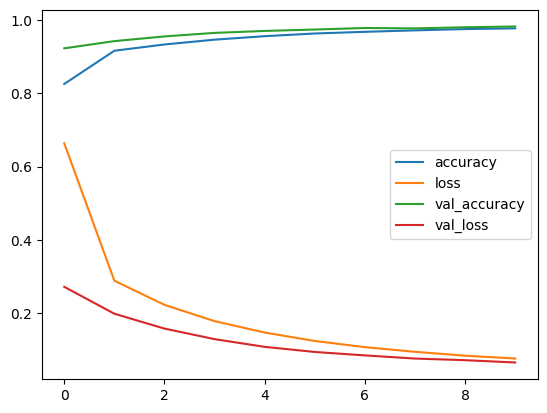

In [22]:
pd.DataFrame(history.history).plot()

In [24]:
model.evaluate(X_test, y_test)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9688 - loss: 0.0492

 11/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9847 - loss: 0.0376  

 21/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9829 - loss: 0.0459

 30/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9813 - loss: 0.0511

 40/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9795 - loss: 0.0558

...

292/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9739 - loss: 0.0777

303/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9740 - loss: 0.0773

311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9741 - loss: 0.0771

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9781 - loss: 0.0690


[0.06902804225683212, 0.9781000018119812]